# Is Capital Really Leaving China? The Global Picture

## The Question

The "China+1" narrative — that global manufacturers and investors are diversifying capital away from China toward alternative destinations — is now conventional wisdom in business media. Does it actually show up in global FDI flow data, at the scale the narrative implies?

## The Answer

Yes, in one specific and verifiable sense: China's own FDI inflows fell 8% in 2025 to an estimated $107.5 billion — the third consecutive year of decline, per UNCTAD. But the more interesting finding is where that global capital actually went instead, and it complicates the popular story: global FDI to *developing* economies as a whole declined 2% in 2025, while flows to *developed* economies surged 43%. East Asia specifically (which includes China) saw inflows fall 17% between 2024 and 2025. Money is moving — but the simple version of "capital is fleeing China for Southeast Asia" doesn't hold at the global level: developing Asia broadly, and South-East Asia specifically, was essentially flat (-1%) in 2025, not surging. Whatever regional capture story exists has to be found at a more granular level than "developing Asia" — which is exactly what Notebooks 02 and 03 test.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

global_fdi = pd.read_csv('../data/processed/global_fdi_by_region.csv')
china_fdi = pd.read_csv('../data/processed/china_fdi_inflows.csv')
global_fdi.head()

,region,year,fdi_inflow_usd_billion
0,World,2023,1288
1,World,2024,1403
2,World,2025,1606
3,Developed economies,2023,430
4,Developed economies,2024,509


In [2]:
# House chart style v2 — consulting-exhibit conventions (MBB-style):
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
ACCENT_1 = '#2a78d6'   # primary accent — the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent — used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series — same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## China's own FDI inflows, in context

In [3]:
china_fdi

,year,fdi_inflow_usd_billion,note
0,2025,107.5,Declined 8% year-on-year; UNCTAD reports this ...


## Where did global FDI growth actually go in 2025?

In [4]:
regions = ['Developed economies', 'Developing economies']
pivot = global_fdi[global_fdi['region'].isin(regions)].pivot(index='year', columns='region', values='fdi_inflow_usd_billion')
pivot

region,Developed economies,Developing economies
year,,
2023,430,859
2024,509,894
2025,728,877


## Visualizing the divergence: developed vs. developing economies

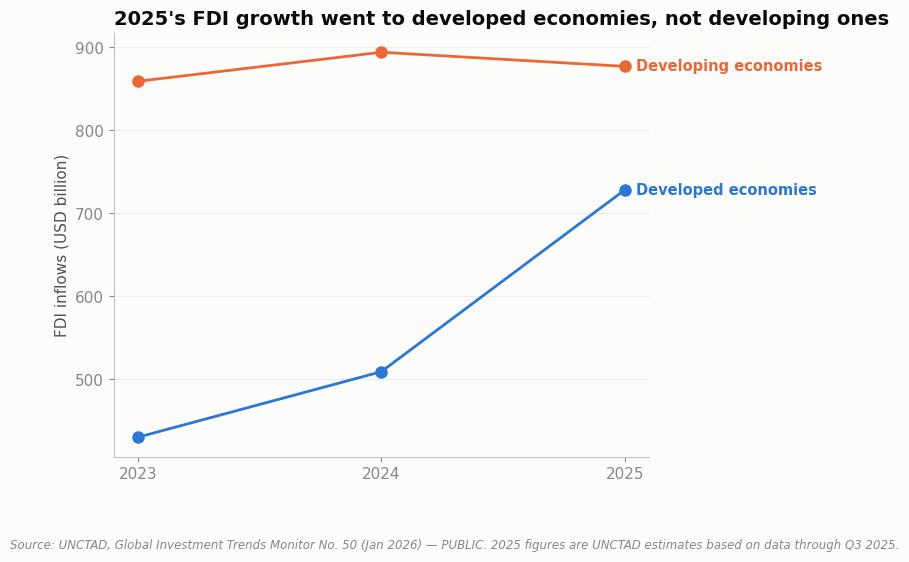

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
dev = global_fdi[global_fdi['region'] == 'Developed economies'].set_index('year')['fdi_inflow_usd_billion']
developing = global_fdi[global_fdi['region'] == 'Developing economies'].set_index('year')['fdi_inflow_usd_billion']

ax.plot(dev.index, dev.values, marker='o', markersize=8, linewidth=2, color=ACCENT_1)
ax.plot(developing.index, developing.values, marker='o', markersize=8, linewidth=2, color=ACCENT_2)

end_label(ax, dev.index[-1], dev.values[-1], 'Developed economies', ACCENT_1, weight='bold')
end_label(ax, developing.index[-1], developing.values[-1], 'Developing economies', ACCENT_2, weight='bold')

ax.set_title("2025's FDI growth went to developed economies, not developing ones", loc='left')
ax.set_ylabel('FDI inflows (USD billion)')
ax.set_xlabel('')
ax.set_xticks([2023, 2024, 2025])
fig.subplots_adjust(right=0.72)

add_source(ax.figure, 'Source: UNCTAD, Global Investment Trends Monitor No. 50 (Jan 2026) — PUBLIC. '
                       '2025 figures are UNCTAD estimates based on data through Q3 2025.')
plt.show()

## Within Asia, the sub-regional split

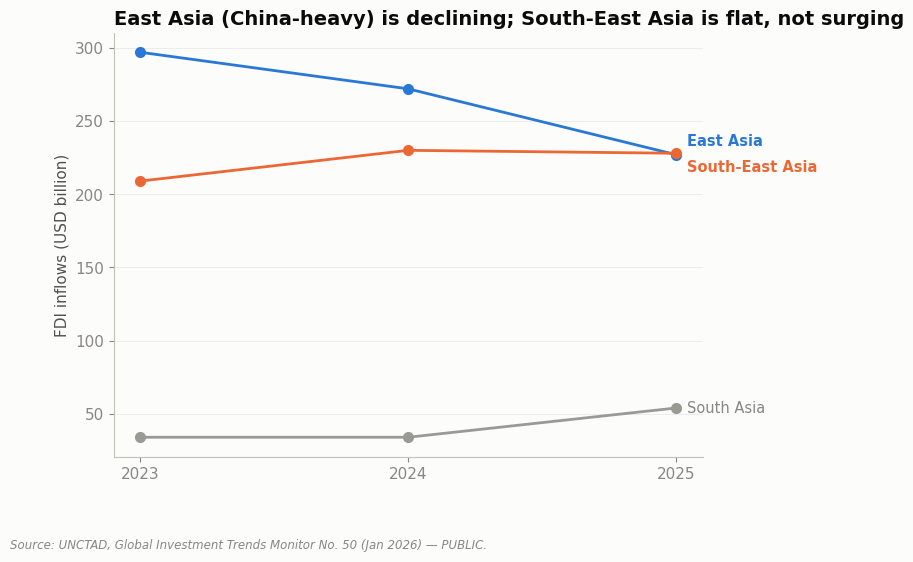

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
asia_regions = ['East Asia', 'South-East Asia', 'South Asia']
colors = {'East Asia': ACCENT_1, 'South-East Asia': ACCENT_2, 'South Asia': GRAY}
weights = {'East Asia': 'bold', 'South-East Asia': 'bold', 'South Asia': 'normal'}

label_offsets = {'East Asia': 10, 'South-East Asia': -10, 'South Asia': 0}
for region in asia_regions:
    d = global_fdi[global_fdi['region'] == region].set_index('year')['fdi_inflow_usd_billion']
    ax.plot(d.index, d.values, marker='o', markersize=7, linewidth=2, color=colors[region])
    label_color = colors[region] if region != 'South Asia' else INK_MUTED
    ax.annotate(region, xy=(d.index[-1], d.values[-1]), xytext=(8, label_offsets[region]),
                textcoords='offset points', va='center', ha='left', fontsize=10.5,
                fontweight=weights[region], color=label_color)

ax.set_title('East Asia (China-heavy) is declining; South-East Asia is flat, not surging', loc='left')
ax.set_ylabel('FDI inflows (USD billion)')
ax.set_xlabel('')
ax.set_xticks([2023, 2024, 2025])
fig.subplots_adjust(right=0.78)

add_source(ax.figure, 'Source: UNCTAD, Global Investment Trends Monitor No. 50 (Jan 2026) — PUBLIC.')
plt.show()


## Strategic Recommendation

- **A business should not treat "capital is leaving China for Southeast Asia" as a validated global trend.** China's own FDI is genuinely declining, but South-East Asia's aggregate inflows were flat in 2025 (-1%), not rising to absorb it. The beneficiary of any diversification, at the global level, is developed economies — not developing Asia broadly.
- **Any real "China+1" capture story has to be found below the regional level.** If Malaysia (or any specific ASEAN country) is winning share, it isn't visible in this global, region-level data — it would show up only in country-specific source-country data, which Notebooks 02 and 03 test directly.

## Confidence & Caveats

- **China's multi-year FDI trend cannot be charted precisely.** UNCTAD's narrative states 2023, 2024, and 2025 all declined, but only the 2025 dollar value ($107.5B) is given in this publication — see `DATA_DICTIONARY.md`.
- **"East Asia" and "South-East Asia" are UN statistical regions, not identical to informal usage of "China" or "ASEAN."** East Asia includes South Korea, Hong Kong, and others alongside China; South-East Asia's UN definition is close to but not identical to the ASEAN Secretariat's 11-member grouping used in Notebook 02.
- **2025 figures throughout are UNCTAD estimates**, based on data through Q3 2025, not yet final figures.

## Why Is This Happening? (Context)

*This section is qualitative, secondary-sourced context explaining the mechanism behind the numbers above — not new PUBLIC/DERIVED primary data. Kept separate from the rest of this notebook for that reason. Full citations in [`references/SOURCES.md`](../references/SOURCES.md).*

UNCTAD's own January 2026 report points to three concrete drivers, not just "developed economies did better":

1. **A large share of 2025's headline FDI growth wasn't real new investment at all.** Over USD 140 billion of the increase came from "conduit flows" — money passing through financial-hub countries on its way somewhere else. Strip those out, and global FDI growth in 2025 was closer to 5%, not 14%.
2. **The growth that was real is highly concentrated in one sector: AI-driven data-centre construction**, which accounted for over a fifth of all new greenfield project value in 2025 (>USD 270 billion announced) — a capital-intensive category that clusters around cheap power, land, and existing digital infrastructure, which developed economies disproportionately have.
3. **Developing economies, especially the poorest ones, faced a genuinely harder financing environment** — three-quarters of least-developed countries saw stagnant or falling inflows, worsened by high borrowing costs and currency volatility.

None of this contradicts this notebook's core finding — it explains it. "Developed economies grew, developing ones didn't" isn't really one story; it's a financial-reporting quirk (conduit flows) plus a sector-specific investment boom (AI infrastructure) plus a genuine financing squeeze on the poorest countries, compressed into a single headline number.

**Source:** UN Trade and Development (UNCTAD), ["Global foreign investment up 14% in 2025, with growth concentrated in developed economies"](https://unctad.org/news/global-foreign-investment-14-2025-growth-concentrated-developed-economies), January 2026.